In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

In [2]:
heart=pd.read_csv('heart_disease.csv')

## EDA (Explor The datasets)

In [3]:
heart.shape

(10000, 21)

In [4]:
heart.duplicated().sum()

np.int64(0)

In [5]:
heart.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [6]:
heart['Heart Disease Status'].value_counts()

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

In [7]:
heart.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')

In [8]:
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [9]:
heart.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

## Graphs

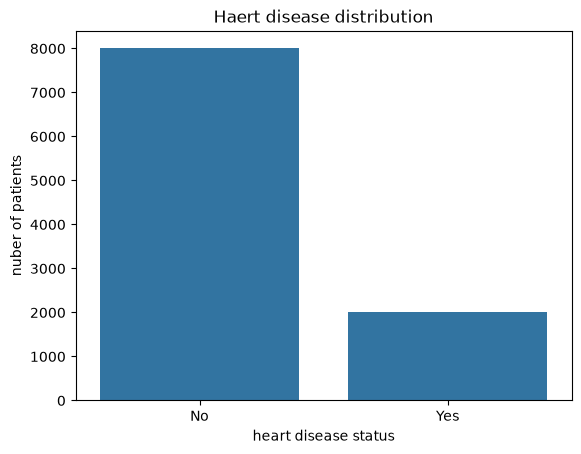

In [10]:
sns.countplot(data=heart,x="Heart Disease Status")
plt.title("Haert disease distribution")
plt.xlabel("heart disease status")
plt.ylabel("nuber of patients")

plt.show()

In [11]:
missing_percent = heart.isnull().sum() / len(heart) * 100
print(missing_percent)

Age                      0.29
Gender                   0.19
Blood Pressure           0.19
Cholesterol Level        0.30
Exercise Habits          0.25
Smoking                  0.25
Family Heart Disease     0.21
Diabetes                 0.30
BMI                      0.22
High Blood Pressure      0.26
Low HDL Cholesterol      0.25
High LDL Cholesterol     0.26
Alcohol Consumption     25.86
Stress Level             0.22
Sleep Hours              0.25
Sugar Consumption        0.30
Triglyceride Level       0.26
Fasting Blood Sugar      0.22
CRP Level                0.26
Homocysteine Level       0.20
Heart Disease Status     0.00
dtype: float64


In [12]:
heart.dtypes

Age                     float64
Gender                      str
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits             str
Smoking                     str
Family Heart Disease        str
Diabetes                    str
BMI                     float64
High Blood Pressure         str
Low HDL Cholesterol         str
High LDL Cholesterol        str
Alcohol Consumption         str
Stress Level                str
Sleep Hours             float64
Sugar Consumption           str
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status        str
dtype: object

- Numerical columns → Fill with Median (preferred) or Mean.  
- Categorical columns → Fill with Mode.

### Numerical col

In [13]:
heart["Age"] = heart["Age"].fillna(heart["Age"].median())
heart["Blood Pressure"] = heart["Blood Pressure"].fillna(heart["Blood Pressure"].median())
heart["Cholesterol Level"] = heart["Cholesterol Level"].fillna(heart["Cholesterol Level"].median())
heart["BMI"] = heart["BMI"].fillna(heart["BMI"].median())
heart["Sleep Hours"] = heart["Sleep Hours"].fillna(heart["Sleep Hours"].median())
heart["Triglyceride Level"] = heart["Triglyceride Level"].fillna(heart["Triglyceride Level"].median())
heart["Fasting Blood Sugar"] = heart["Fasting Blood Sugar"].fillna(heart["Fasting Blood Sugar"].median())
heart["CRP Level"] = heart["CRP Level"].fillna(heart["CRP Level"].median())
heart["Homocysteine Level"] = heart["Homocysteine Level"].fillna(heart["Homocysteine Level"].median())

### categorical col

In [14]:
heart["Gender"] = heart["Gender"].fillna(heart["Gender"].mode()[0])
heart["Exercise Habits"] = heart["Exercise Habits"].fillna(heart["Exercise Habits"].mode()[0])
heart["Smoking"] = heart["Smoking"].fillna(heart["Smoking"].mode()[0])
heart["Family Heart Disease"] = heart["Family Heart Disease"].fillna(heart["Family Heart Disease"].mode()[0])
heart["Diabetes"] = heart["Diabetes"].fillna(heart["Diabetes"].mode()[0])
heart["High Blood Pressure"] = heart["High Blood Pressure"].fillna(heart["High Blood Pressure"].mode()[0])
heart["Low HDL Cholesterol"] = heart["Low HDL Cholesterol"].fillna(heart["Low HDL Cholesterol"].mode()[0])
heart["High LDL Cholesterol"] = heart["High LDL Cholesterol"].fillna(heart["High LDL Cholesterol"].mode()[0])
heart["Alcohol Consumption"] = heart["Alcohol Consumption"].fillna(heart["Alcohol Consumption"].mode()[0])
heart["Stress Level"] = heart["Stress Level"].fillna(heart["Stress Level"].mode()[0])
heart["Sugar Consumption"] = heart["Sugar Consumption"].fillna(heart["Sugar Consumption"].mode()[0])

In [15]:
heart.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64

In [16]:
heart['Heart Disease Status'].value_counts()

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

In [17]:
heart['Heart Disease Status']=heart['Heart Disease Status'].map({
    'Yes':1,
    'No':0
})

## Feature Selection


In [18]:
x=heart.drop("Heart Disease Status",axis=1)
y=heart['Heart Disease Status']

## Split data

In [19]:
x_trainx,X_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model=LogisticRegression()
model.fit(x_trainx,y_train)

ValueError: could not convert string to float: 'Male'